In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/online_retail_II.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(34335)

In [8]:
df.shape

(1067371, 8)

Problems Found :

Description: 4,382 missing values
Customer ID: 243,007 missing values 
InvoiceDate is stored as text 
34,335 fully duplicate rows

In [9]:
df = pd.read_csv('../data/online_retail_II.csv', encoding='ISO-8859-1')

In [10]:
df.shape

(1067371, 8)

In [11]:
df = df[~ df ["Invoice"].astype(str).str.startswith("C")]

# C indicated the cancelled orders 

In [12]:
df.shape

(1047877, 8)

In [13]:
df = df.dropna(subset = ["Customer ID"])

# Dropping missing customer id'd

In [14]:
df.shape

(805620, 8)

In [15]:
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

In [16]:
df.shape

(805549, 8)

In [17]:
df = df.drop_duplicates()
df.shape

(779425, 8)

In [18]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 53.5+ MB


In [19]:
df["TotalPrice"] = df["Quantity"] * df["Price"]
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [20]:
df.to_csv("../data/online_retail_cleaned.csv", index = False)

#Saving cleaned data set seperately

In [21]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### EDA(Exploratory Data Analysis)

In [22]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly_revenue = df.groupby("InvoiceMonth")["TotalPrice"].sum()
monthly_revenue

InvoiceMonth
2009-12     683504.010
2010-01     555802.672
2010-02     504558.956
2010-03     696978.471
2010-04     591982.002
2010-05     597833.380
2010-06     636371.130
2010-07     589736.170
2010-08     602224.600
2010-09     829013.951
2010-10    1033112.010
2010-11    1166460.022
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517208.440
Freq: M, Name: TotalPrice, dtype: float64

### Visualization

In [23]:
import matplotlib.pyplot as plt

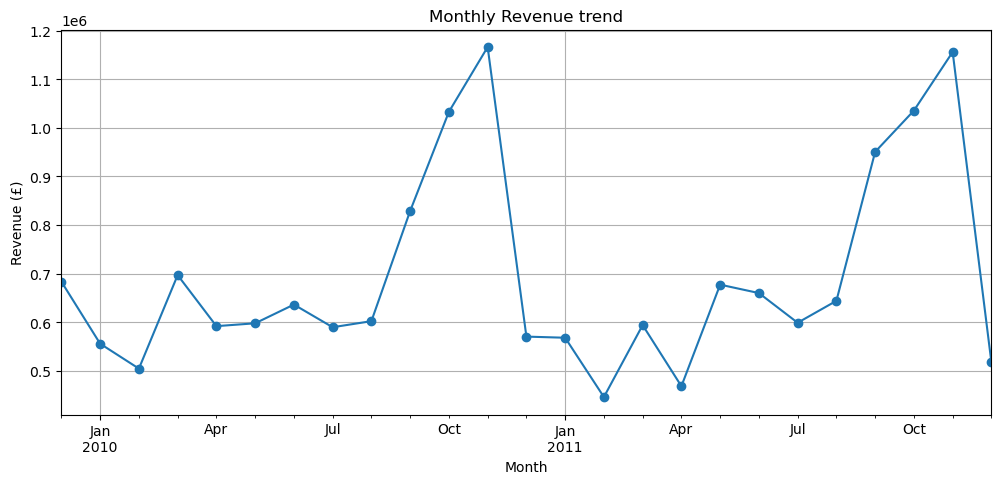

In [24]:
monthly_revenue.plot(kind = "line",figsize = (12,5),marker = "o")

plt.title("Monthly Revenue trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.grid(True)
plt.show()

In [25]:
top_products = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending = False).head(10)
top_products

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: TotalPrice, dtype: float64

In [26]:
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending = False).head(10)
top_countries

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: TotalPrice, dtype: float64

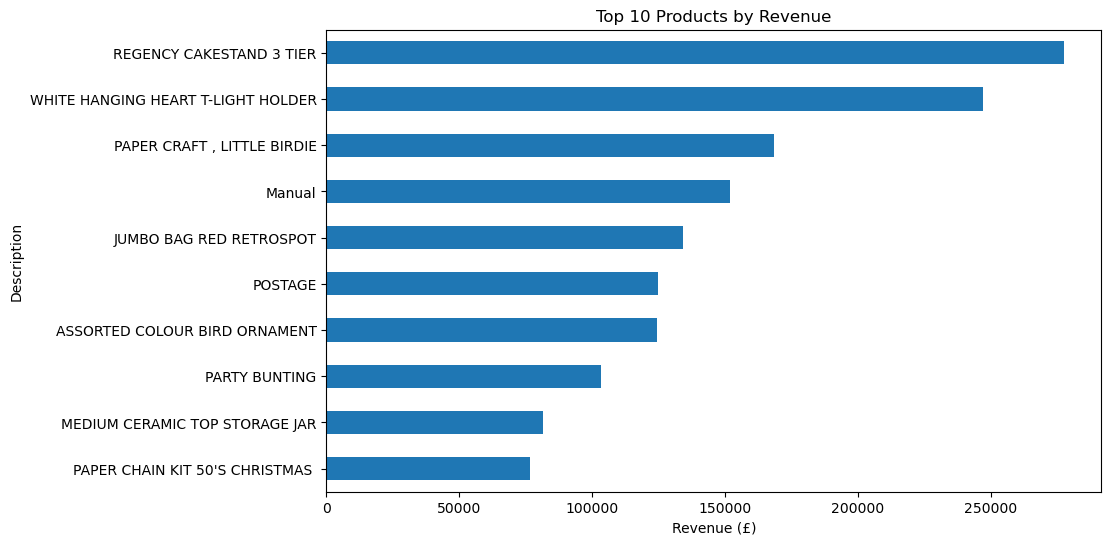

In [27]:
top_products.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.gca().invert_yaxis()
plt.show()

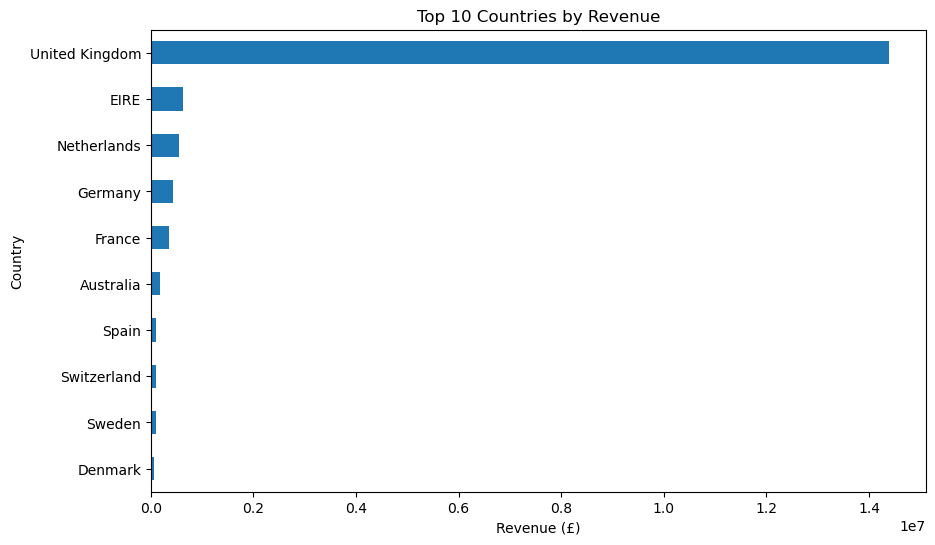

In [28]:
top_countries.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.gca().invert_yaxis()
plt.show()

In [29]:
monthly_orders = df.groupby("InvoiceMonth")["Invoice"].nunique()
monthly_orders

InvoiceMonth
2009-12    1512
2010-01    1011
2010-02    1104
2010-03    1524
2010-04    1329
2010-05    1377
2010-06    1497
2010-07    1381
2010-08    1293
2010-09    1689
2010-10    2133
2010-11    2587
2010-12    1400
2011-01     987
2011-02     997
2011-03    1321
2011-04    1149
2011-05    1555
2011-06    1393
2011-07    1331
2011-08    1280
2011-09    1755
2011-10    1929
2011-11    2657
2011-12     778
Freq: M, Name: Invoice, dtype: int64

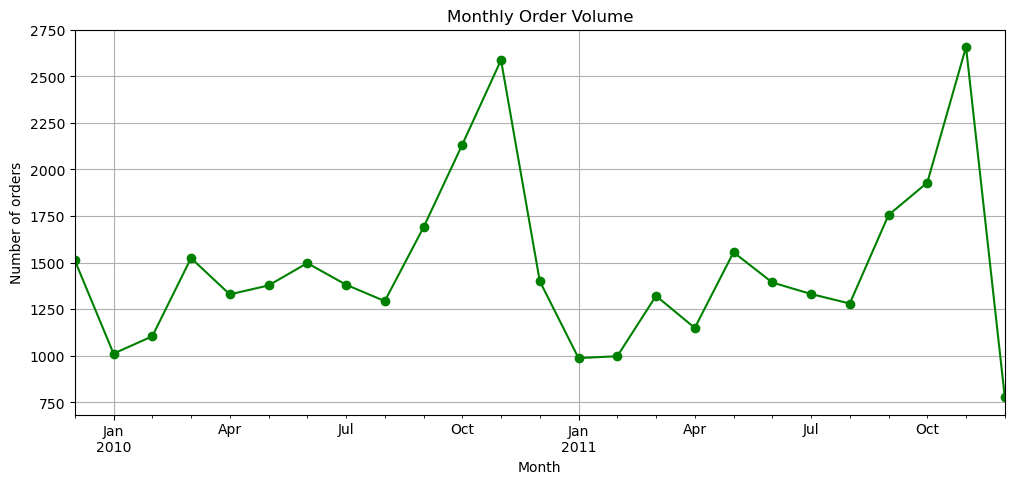

In [32]:
monthly_orders.plot(kind = "line",figsize = (12,5),marker = "o",color = "green")
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of orders")
plt.grid(True)
plt.show()

In [33]:
order_values = df.groupby("Invoice")["TotalPrice"].sum()
order_values.describe()

count     36969.000000
mean        469.983074
std        1359.741927
min           0.380000
25%         157.920000
50%         303.040000
75%         477.280000
max      168469.600000
Name: TotalPrice, dtype: float64

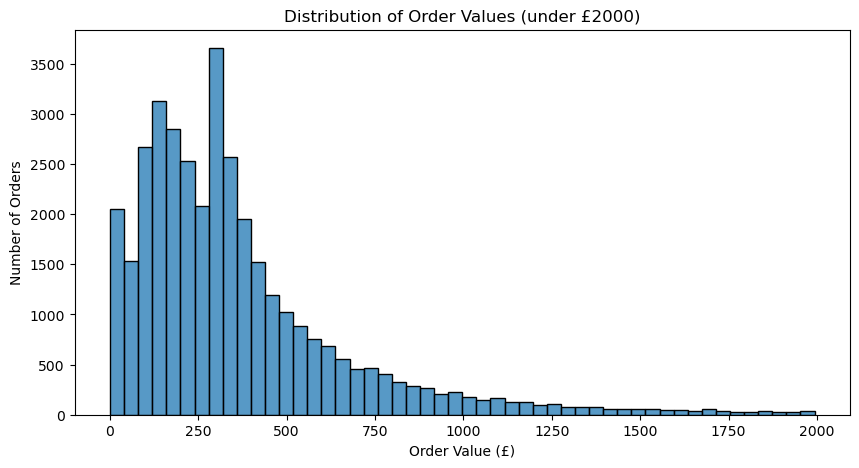

In [35]:
import seaborn as sns 
plt.figure(figsize=(10,5))
sns.histplot(order_values[order_values < 2000], bins=50)
plt.title('Distribution of Order Values (under £2000)')
plt.xlabel('Order Value (£)')
plt.ylabel('Number of Orders')
plt.show()

In [36]:
customer_frequency = df.groupby("Customer ID")["Invoice"].nunique()
customer_frequency.describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64

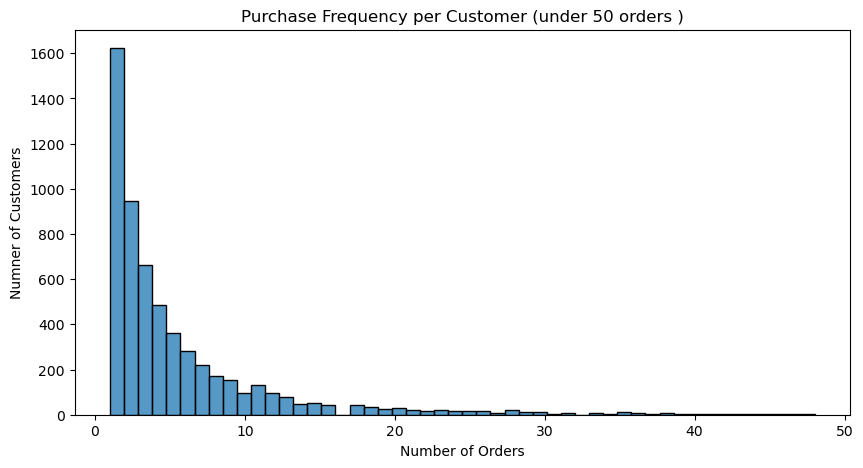

In [37]:
plt.figure(figsize = (10,5))
sns.histplot(customer_frequency[customer_frequency < 50 ],bins = 50)
plt.title("Purchase Frequency per Customer (under 50 orders )")
plt.xlabel("Number of Orders")
plt.ylabel("Numner of Customers")
plt.show()